--- VALIDAÇÃO DA LÓGICA ---
Amigos: 0 | Chuva: 0 -> z:  -2 | Resultado: FICO (0)
Amigos: 0 | Chuva: 1 -> z:  -7 | Resultado: FICO (0)
Amigos: 1 | Chuva: 0 -> z:   8 | Resultado: VOU! (1)
Amigos: 1 | Chuva: 1 -> z:   3 | Resultado: VOU! (1)


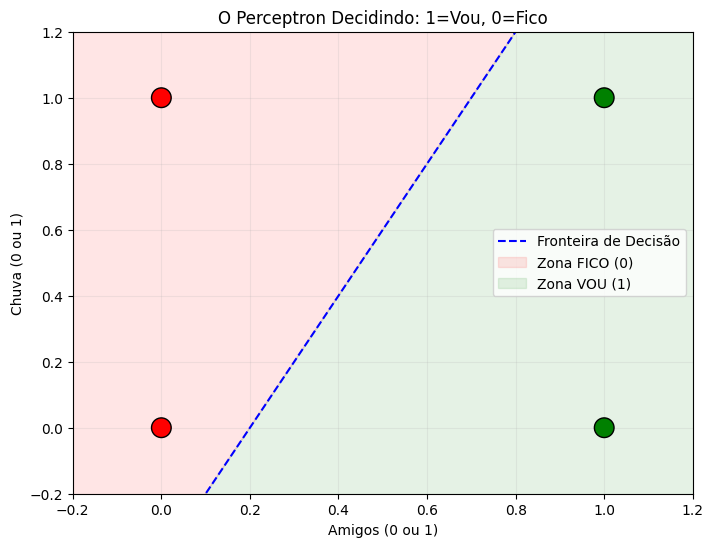

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurações (Ajuste para testar)
w_amigos = 10
w_chuva = -5
bias = -2

# 2. Cenários (x1=Amigos, x2=Chuva)
cenarios = [[0,0], [0,1], [1,0], [1,1]]

pontos_x, pontos_y, cores = [], [], []

print("--- VALIDAÇÃO DA LÓGICA ---")
for x in cenarios:
    z = (x[0] * w_amigos) + (x[1] * w_chuva) + bias
    decisao = 1 if z >= 0 else 0

    status = "VOU! (1)" if decisao == 1 else "FICO (0)"
    print(f"Amigos: {x[0]} | Chuva: {x[1]} -> z: {z:3} | Resultado: {status}")

    pontos_x.append(x[0])
    pontos_y.append(x[1])
    cores.append('green' if decisao == 1 else 'red')

plt.figure(figsize=(8, 6))

# Reta de Decisão (z = 0)
# Equação da reta: w1*x1 + w2*x2 + b = 0  =>  x2 = (-w1*x1 - b) / w2
x_linha = np.linspace(-0.5, 1.5, 100)
if w_chuva != 0:
    y_linha = (-w_amigos * x_linha - bias) / w_chuva
    plt.plot(x_linha, y_linha, color='blue', linestyle='--', label='Fronteira de Decisão')

    # Colorir regiões
    plt.fill_between(x_linha, y_linha, 2, color='red', alpha=0.1, label='Zona FICO (0)')
    plt.fill_between(x_linha, y_linha, -1, color='green', alpha=0.1, label='Zona VOU (1)')
else:
    plt.axvline(x=-bias/w_amigos, color='blue', linestyle='--', label='Fronteira de Decisão')

plt.scatter(pontos_x, pontos_y, c=cores, s=200, edgecolors='black', zorder=5)

plt.title("O Perceptron Decidindo: 1=Vou, 0=Fico")
plt.xlabel("Amigos (0 ou 1)")
plt.ylabel("Chuva (0 ou 1)")
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()